# IPWG-Net

This notebook illustrates how to use the pre-trained IPWG-Net models to run inference on the SatRain testing data. Three pre-trained models are available for GMI, GEO-IR, and GEO observations, respectively. Using the IPWG-Net with other input configurations will require retraining using the scripts provided in the ``models/ipwg_net`` directory.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

## Downloading the Models.

The training models are available from [hf.co/simonpf/ipwg_net](hr.co/simonpf/ipwg_net). The code below download the models.

In [2]:
from huggingface_hub import snapshot_download

path = snapshot_download(
    repo_id="simonpf/ipwg_net",
)
files =  sorted(list(Path(path).glob("*.pt")))

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

## Loading the Models

The code below loads the models and their input input configurations. The input configurations are stored with the model to ensure that the right input configuration can be loaded for each model.

In [3]:
from satrain_models.encoder_decoder import load_model
from satrain_models.lightning import SatRainEstimationModule

models = {}
satrain_configs = {}
for path in files:
    sensor = path.stem.split("_")[-1]
    model, satrain_config = load_model(path)
    models[sensor] = SatRainEstimationModule(model.eval())
    satrain_configs[sensor] = satrain_config

Below we create the retrieval callback functions that perform the inference. For this, we pass the ``satrain_config``, which specifies the input data expected by the model, and a ``compute_config`` that defines which compute resources will be used to perform the inference. The results is a dict hodling the retrieval callbacks for the three pretrained models.

In [4]:
from satrain_models.config import ComputeConfig

# Configure compute environment
compute_config = ComputeConfig(
    accelerator="cuda",
    devices=[0]
)

retrieval_callbacks = {
    name: models[name].get_retrieval_fn(
        satrain_config=satrain_configs[name],
        compute_config=compute_config
    ) for name in models.keys()
}

## Retrieval Results

Finally, we can use the models to run the retrieval on a test-set scene and plot the results using the ``plot_retrieval_results_function`` of the evaluator.

In [10]:
from satrain.evaluation import Evaluator

retrieval_input = []
for cfg in satrain_configs.values():
    retrieval_input += cfg.retrieval_input 

evaluator = Evaluator(
    base_sensor="gmi",
    geometry="gridded",
    domain="conus",
    retrieval_input=retrieval_input
)

In [11]:
models = {
    "Geo, 11 um": retrieval_callbacks["ir"],
    "Geo, multi-spectral": retrieval_callbacks["geo"],
    "PMW": retrieval_callbacks["gmi"],
}

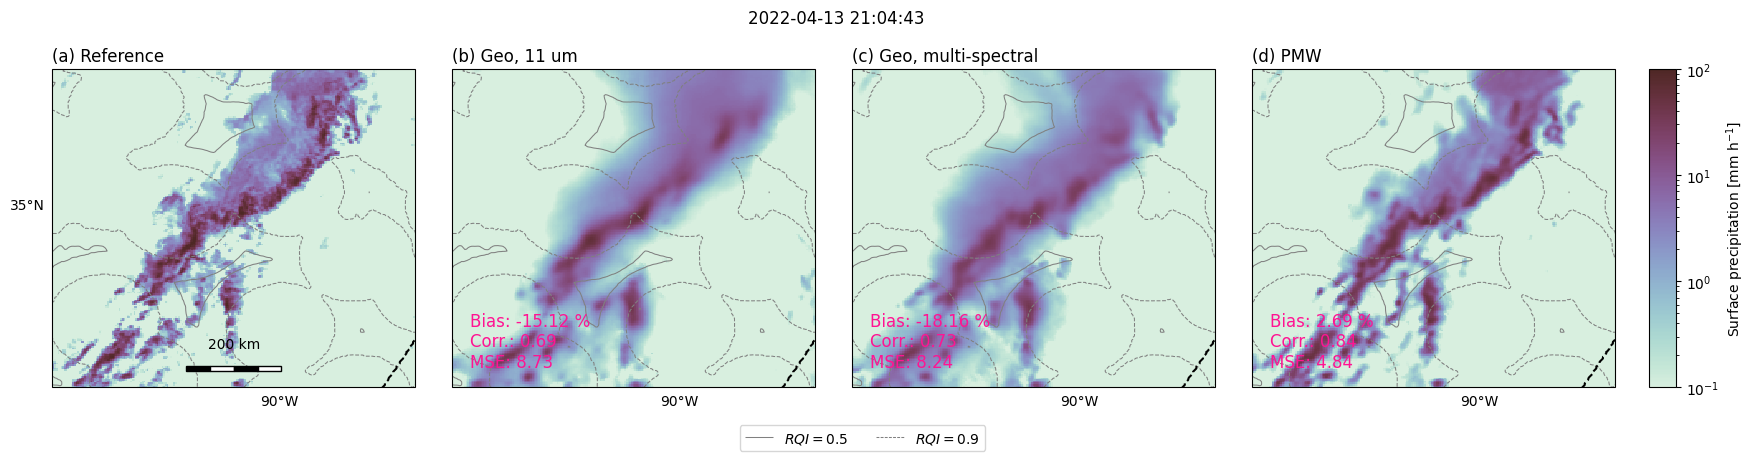

In [12]:
evaluator.plot_retrieval_results(
    811,
    models,
    batch_size=32,
    tile_size=256,
    overlap=64,
    include_metrics=True,
    swath_boundaries=True,
    bounds=(-95, 31, -87, 38)
);